In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the local environment
df = pd.read_csv('Restaurant_Dataset.csv')

# Verify that the dataset structure is correct for Level 2 analysis
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


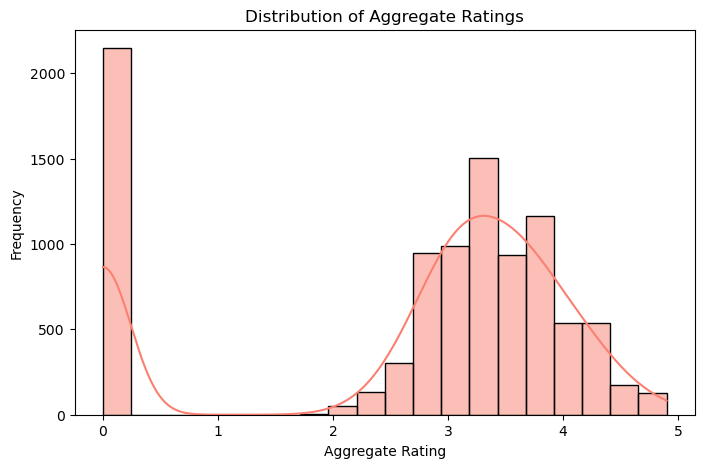

The most frequent rating given to restaurants is: 0.0
Average number of votes received: 156.91


In [2]:
# Visualize the distribution of aggregate ratings using a histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['Aggregate rating'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Frequency')
plt.show()

# Determine the most common rating range value (Mode)
most_common_rating = df['Aggregate rating'].value_counts().idxmax()
print(f"The most frequent rating given to restaurants is: {most_common_rating}")

# Calculate the average number of votes received by restaurants
avg_votes = df['Votes'].mean()
print(f"Average number of votes received: {avg_votes:.2f}")

In [3]:
# Identify the most common combinations of cuisines in the dataset
common_combinations = df['Cuisines'].value_counts().head(10)
print("Top 10 Most Common Cuisine Combinations:\n", common_combinations)

# Check if specific cuisine combinations tend to have higher average ratings
top_combos_list = common_combinations.index
avg_rating_combos = df[df['Cuisines'].isin(top_combos_list)].groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)
print("\nAverage Ratings for Top Cuisine Combinations:\n", avg_rating_combos)

Top 10 Most Common Cuisine Combinations:
 Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

Average Ratings for Top Cuisine Combinations:
 Cuisines
Cafe                              2.890970
North Indian, Mughlai             2.888623
North Indian, Mughlai, Chinese    2.568528
North Indian, Chinese             2.421722
Bakery, Desserts                  2.317647
Street Food                       2.161745
Fast Food                         2.118362
Chinese                           2.042090
Bakery                            1.924312
North Indian                      1.672329
Name: Aggregate rating, dtype: float64


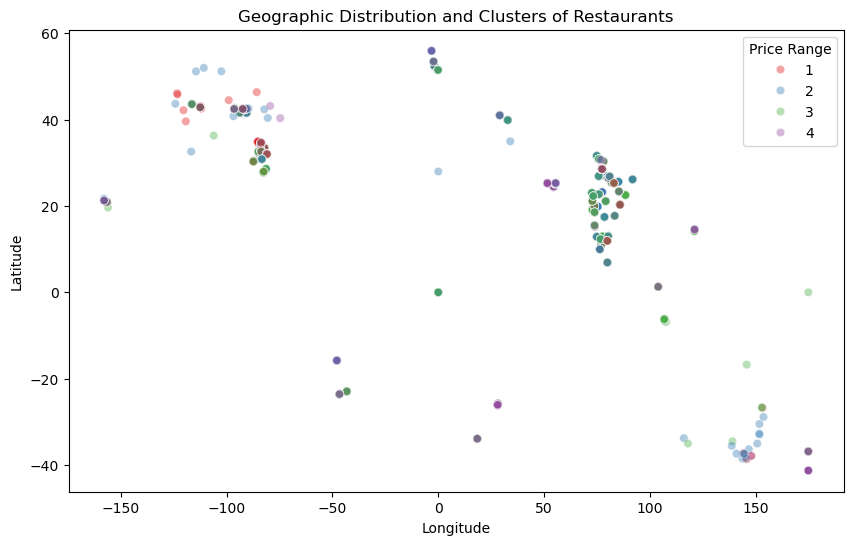

In [4]:
# Plot restaurant locations using latitude and longitude coordinates to identify clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Longitude', y='Latitude', alpha=0.4, hue='Price range', palette='Set1')
plt.title('Geographic Distribution and Clusters of Restaurants')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Price Range')
plt.show()

In [5]:
# Identify the presence of restaurant chains based on duplicate names
chain_counts = df['Restaurant Name'].value_counts()
chains = chain_counts[chain_counts > 1]
print(f"Total number of unique restaurant chains identified: {len(chains)}")

# Extract data for the top 5 largest chains to analyze their rating and popularity
top_chains_df = df[df['Restaurant Name'].isin(chains.head(5).index)]
chain_analysis = top_chains_df.groupby('Restaurant Name').agg({'Aggregate rating': 'mean', 'Votes': 'sum'})
print("\nPerformance and Popularity Analysis of Top 5 Chains:\n", chain_analysis)

Total number of unique restaurant chains identified: 734

Performance and Popularity Analysis of Top 5 Chains:
                   Aggregate rating  Votes
Restaurant Name                          
Cafe Coffee Day           2.419277   2428
Domino's Pizza            2.740506   6643
Green Chick Chop          2.672549    964
McDonald's                3.339583   5291
Subway                    2.907937   6124
